## EDA for energy optimization data set

In [1]:
from google.colab import drive
drive.mount('/content/drive')
print("✅ Drive mounted!")

Mounted at /content/drive
✅ Drive mounted!


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.style.use('seaborn-v0_8')

meter_map = {0: 'Electricity', 1: 'Chilled Water', 2: 'Steam', 3: 'Hot Water'}

print("✅ Libraries imported!")

✅ Libraries imported!


In [3]:
df = pd.read_parquet('/content/drive/MyDrive/hvac_project/merged_energy_data.parquet')
print(f"✅ Data loaded!")
print(f"   Shape: {df.shape}")

✅ Data loaded!
   Shape: (20216100, 16)


In [4]:
df = df.drop(columns=['floor_count', 'year_built'])
print(f"✅ Dropped floor_count and year_built!")
print(f"   Shape: {df.shape}")

✅ Dropped floor_count and year_built!
   Shape: (20216100, 14)


In [5]:
weather_cols = ['air_temperature', 'dew_temperature',
                'wind_speed', 'wind_direction', 'sea_level_pressure']
df[weather_cols] = df[weather_cols].fillna(method='ffill')
df['cloud_coverage']    = df['cloud_coverage'].fillna(method='ffill').fillna(0)
df['precip_depth_1_hr'] = df['precip_depth_1_hr'].fillna(0)

print(f"✅ Missing values handled!")
print(f"   Remaining missing: {df.isnull().sum().sum()}")

✅ Missing values handled!
   Remaining missing: 0


In [6]:
before = len(df)
df = df.drop_duplicates()
print(f"✅ Duplicates removed: {before - len(df)}")
print(f"   Shape: {df.shape}")

✅ Duplicates removed: 0
   Shape: (20216100, 14)


In [7]:
before = len(df)
df = df[df['meter_reading'] >= 0]
print(f"✅ Negative readings removed: {before - len(df)}")
print(f"   Shape: {df.shape}")

✅ Negative readings removed: 0
   Shape: (20216100, 14)


In [8]:
hard_caps = {0: 1629.61, 1: 5449.22, 2: 5449.22, 3: 3676.39}

for meter_id, cap in hard_caps.items():
    df.loc[df['meter'] == meter_id, 'meter_reading'] = \
        df.loc[df['meter'] == meter_id, 'meter_reading'].clip(upper=cap)
    print(f"   {meter_map[meter_id]:15} → capped at {cap}")

print(f"\n✅ Outliers capped!")

   Electricity     → capped at 1629.61
   Chilled Water   → capped at 5449.22
   Steam           → capped at 5449.22
   Hot Water       → capped at 3676.39

✅ Outliers capped!


OUTLIER VISUALIZATION — BOXPLOTS


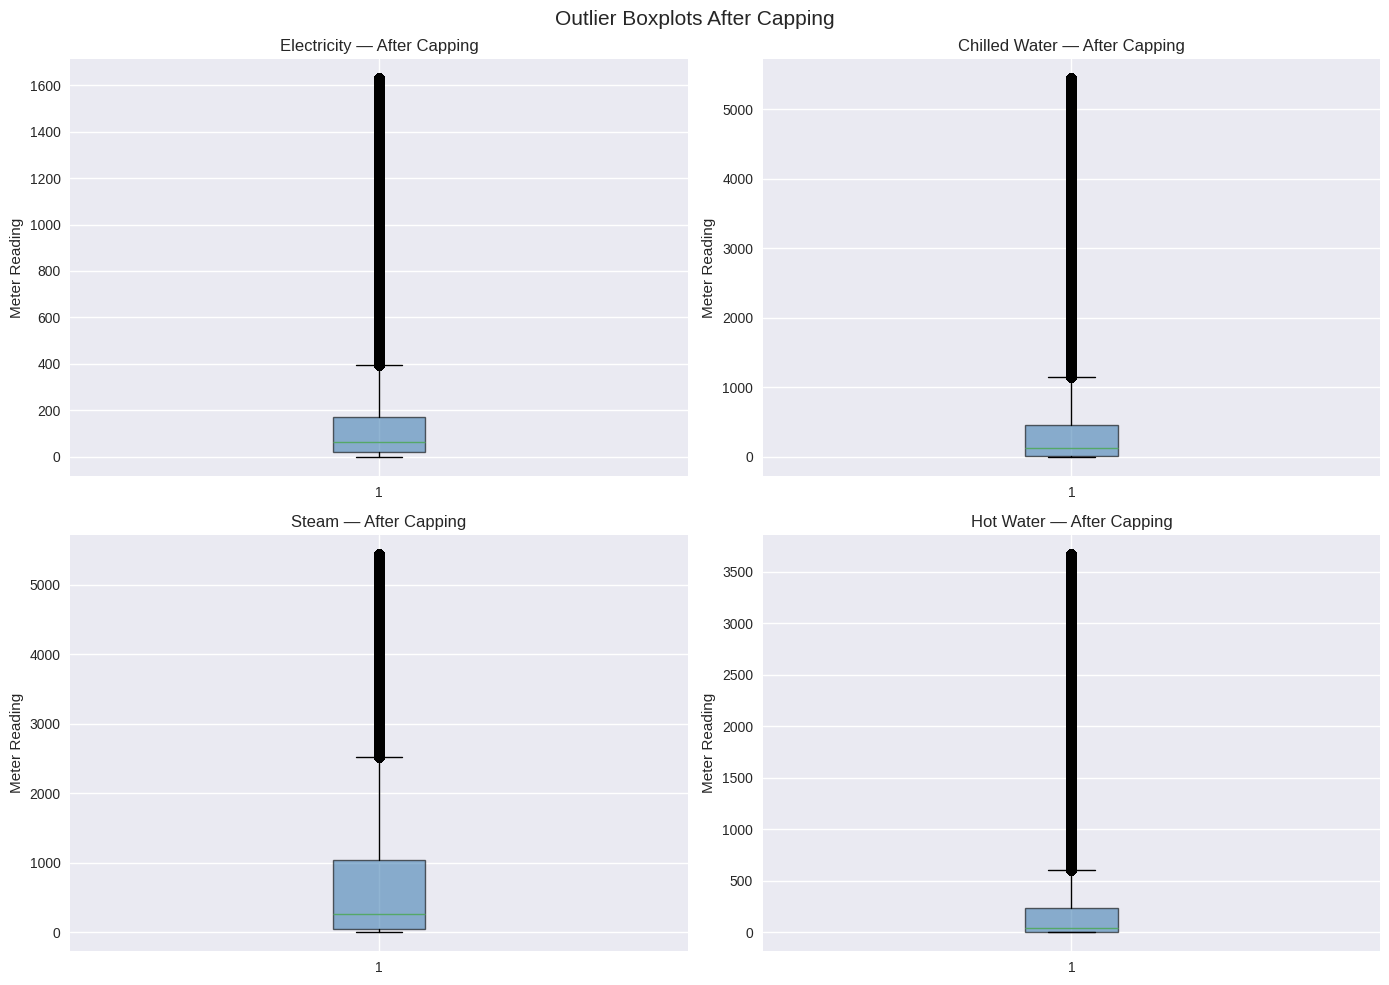

In [24]:
print("=" * 50)
print("OUTLIER VISUALIZATION — BOXPLOTS")
print("=" * 50)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, (meter_id, meter_name) in enumerate(meter_map.items()):
    ax = axes[i//2][i%2]
    subset = df[df['meter'] == meter_id]['meter_reading']
    ax.boxplot(subset, vert=True, patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.6))
    ax.set_title(f'{meter_name} — After Capping')
    ax.set_ylabel('Meter Reading')

plt.suptitle('Outlier Boxplots After Capping', fontsize=15)
plt.tight_layout()
plt.show()

In [9]:
df['meter_name'] = df['meter'].map(meter_map)
print(f"✅ meter_name column added!")
print(f"   {df['meter_name'].value_counts().to_dict()}")

✅ meter_name column added!
   {'Electricity': 12060910, 'Chilled Water': 4182440, 'Steam': 2708713, 'Hot Water': 1264037}


In [10]:
print("--- Verification ---")
print(f"Shape          : {df.shape}")
print(f"Missing values : {df.isnull().sum().sum()}")
print(f"Negative vals  : {(df['meter_reading'] < 0).sum()}")
print(f"\nMax per meter type:")
for meter_id, meter_name in meter_map.items():
    print(f"  {meter_name:15} → {df[df['meter'] == meter_id]['meter_reading'].max():.2f}")

df.to_parquet('/content/drive/MyDrive/hvac_project/eda_cleaned_data.parquet', index=False)
print("\n✅ Cleaned data saved to Drive!")

--- Verification ---
Shape          : (20216100, 15)
Missing values : 0
Negative vals  : 0

Max per meter type:
  Electricity     → 1629.61
  Chilled Water   → 5449.22
  Steam           → 5449.22
  Hot Water       → 3676.39

✅ Cleaned data saved to Drive!


In [25]:
print("--- Summary of Cleaning ---")
print(f"  Columns dropped     : floor_count, year_built")
print(f"  Missing values      : All handled")
print(f"  Duplicates removed  : 0")
print(f"  Negative readings   : 0")
print(f"  Outliers            : Capped per meter type")
print(f"  Final shape         : {df.shape}")

--- Summary of Cleaning ---
  Columns dropped     : floor_count, year_built
  Missing values      : All handled
  Duplicates removed  : 0
  Negative readings   : 0
  Outliers            : Capped per meter type
  Final shape         : (20216100, 20)


In [13]:
df.head()

,building_id,meter,timestamp,meter_reading,site_id,primary_use,square_feet,air_temperature,cloud_coverage,dew_temperature,precip_depth_1_hr,sea_level_pressure,wind_direction,wind_speed,meter_name
0,0,0,2016-01-01,0.00,0,Education,7432,25.00,6.00,20.00,0.00,1019.70,0.00,0.00,Electricity
1,1,0,2016-01-01,0.00,0,Education,2720,25.00,6.00,20.00,0.00,1019.70,0.00,0.00,Electricity
2,2,0,2016-01-01,0.00,0,Education,5376,25.00,6.00,20.00,0.00,1019.70,0.00,0.00,Electricity
3,3,0,2016-01-01,0.00,0,Education,23685,25.00,6.00,20.00,0.00,1019.70,0.00,0.00,Electricity
4,4,0,2016-01-01,0.00,0,Education,116607,25.00,6.00,20.00,0.00,1019.70,0.00,0.00,Electricity


In [14]:
df.tail()

,building_id,meter,timestamp,meter_reading,site_id,primary_use,square_feet,air_temperature,cloud_coverage,dew_temperature,precip_depth_1_hr,sea_level_pressure,wind_direction,wind_speed,meter_name
20216095,1444,0,2016-12-31 23:00:00,8.75,15,Entertainment/public assembly,19619,1.70,4.00,-5.60,-1.00,1008.50,180.00,8.80,Electricity
20216096,1445,0,2016-12-31 23:00:00,4.83,15,Education,4298,1.70,4.00,-5.60,-1.00,1008.50,180.00,8.80,Electricity
20216097,1446,0,2016-12-31 23:00:00,0.00,15,Entertainment/public assembly,11265,1.70,4.00,-5.60,-1.00,1008.50,180.00,8.80,Electricity
20216098,1447,0,2016-12-31 23:00:00,159.57,15,Lodging/residential,29775,1.70,4.00,-5.60,-1.00,1008.50,180.00,8.80,Electricity
20216099,1448,0,2016-12-31 23:00:00,2.85,15,Office,92271,1.70,4.00,-5.60,-1.00,1008.50,180.00,8.80,Electricity


In [12]:
df.describe()

,building_id,meter,timestamp,meter_reading,site_id,square_feet,air_temperature,cloud_coverage,dew_temperature,precip_depth_1_hr,sea_level_pressure,wind_direction,wind_speed
count,20216100.00,20216100.00,20216100,20216100.00,20216100.00,20216100.00,20216100.00,20216100.00,20216100.00,20216100.00,20216100.00,20216100.00,20216100.00
mean,799.28,0.66,2016-07-03 22:59:40.301601792,332.78,7.99,107782.98,15.98,2.29,7.74,0.65,1016.13,172.81,3.38
min,0.00,0.00,2016-01-01 00:00:00,0.00,0.00,283.00,-28.90,0.00,-35.00,-1.00,968.20,0.00,0.00
25%,393.00,0.00,2016-04-05 21:00:00,18.30,3.00,32527.00,8.40,0.00,0.00,0.00,1011.80,70.00,2.10
50%,895.00,0.00,2016-07-04 17:00:00,78.78,9.00,72709.00,16.70,2.00,8.90,0.00,1016.10,180.00,3.10
75%,1179.00,1.00,2016-10-02 22:00:00,267.98,13.00,139113.00,23.90,4.00,16.10,0.00,1020.50,280.00,4.60
max,1448.00,3.00,2016-12-31 23:00:00,5449.22,15.00,875000.00,47.20,9.00,26.10,343.00,1045.50,360.00,19.00
std,426.91,0.93,NaN,771.72,5.10,117142.44,10.95,2.61,10.19,6.75,6.99,113.94,2.27


In [15]:
print("=" * 50)
print("STEP 1 — UNDERSTANDING THE DATA")
print("=" * 50)

print(f"\nRows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")

print("\n--- Column Names & Data Types ---")
print(df.dtypes)

print("\n--- First 5 Rows ---")
print(df.head())

print("\n--- Last 5 Rows ---")
print(df.tail())

print("\n--- Basic Statistics ---")
print(df.describe())

STEP 1 — UNDERSTANDING THE DATA

Rows    : 20,216,100
Columns : 15

--- Column Names & Data Types ---
building_id                    int64
meter                          int64
timestamp             datetime64[ns]
meter_reading                float64
site_id                        int64
primary_use                   object
square_feet                    int64
air_temperature              float64
cloud_coverage               float64
dew_temperature              float64
precip_depth_1_hr            float64
sea_level_pressure           float64
wind_direction               float64
wind_speed                   float64
meter_name                    object
dtype: object

--- First 5 Rows ---
   building_id  meter  timestamp  meter_reading  site_id primary_use  \
0            0      0 2016-01-01           0.00        0   Education   
1            1      0 2016-01-01           0.00        0   Education   
2            2      0 2016-01-01           0.00        0   Education   
3            3     

In [16]:
print("=" * 50)
print("STEP 2 — MISSING VALUE VERIFICATION")
print("=" * 50)

missing_count = df.isnull().sum()
missing_pct   = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count' : missing_count,
    'Missing %'     : missing_pct
}).sort_values('Missing %', ascending=False)

print(missing_df)

if missing_count.sum() == 0:
    print("\n✅ No missing values — data is clean!")
else:
    print(f"\n⚠️ {missing_count.sum()} missing values found!")

print("\n--- Duplicate Check ---")
print(f"Duplicates : {df.duplicated().sum():,}")

print("\n--- Negative Readings Check ---")
print(f"Negative readings : {(df['meter_reading'] < 0).sum():,}")

print("\n--- Max Per Meter Type ---")
for meter_id, meter_name in meter_map.items():
    max_val = df[df['meter'] == meter_id]['meter_reading'].max()
    print(f"  {meter_name:15} → {max_val:.2f}")

STEP 2 — MISSING VALUE VERIFICATION
                    Missing Count  Missing %
building_id                     0       0.00
meter                           0       0.00
timestamp                       0       0.00
meter_reading                   0       0.00
site_id                         0       0.00
primary_use                     0       0.00
square_feet                     0       0.00
air_temperature                 0       0.00
cloud_coverage                  0       0.00
dew_temperature                 0       0.00
precip_depth_1_hr               0       0.00
sea_level_pressure              0       0.00
wind_direction                  0       0.00
wind_speed                      0       0.00
meter_name                      0       0.00

✅ No missing values — data is clean!

--- Duplicate Check ---
Duplicates : 0

--- Negative Readings Check ---
Negative readings : 0

--- Max Per Meter Type ---
  Electricity     → 1629.61
  Chilled Water   → 5449.22
  Steam           → 5449.22

In [26]:
missing_pct_filtered = missing_pct[missing_pct > 0]
if len(missing_pct_filtered) > 0:
    plt.figure(figsize=(10, 6))
    missing_pct_filtered.sort_values().plot(kind='barh', color='tomato')
    plt.title('Missing Value Percentage per Column')
    plt.xlabel('Missing %')
    plt.tight_layout()
    plt.show()
else:
    print("✅ No missing values to plot!")

✅ No missing values to plot!


STEP 3 — TARGET VARIABLE ANALYSIS

Total readings    : 20,216,100
Zero readings     : 1,873,976 (9.3%)
Negative readings : 0
Mean reading      : 332.78
Median reading    : 78.78
Max reading       : 5449.22


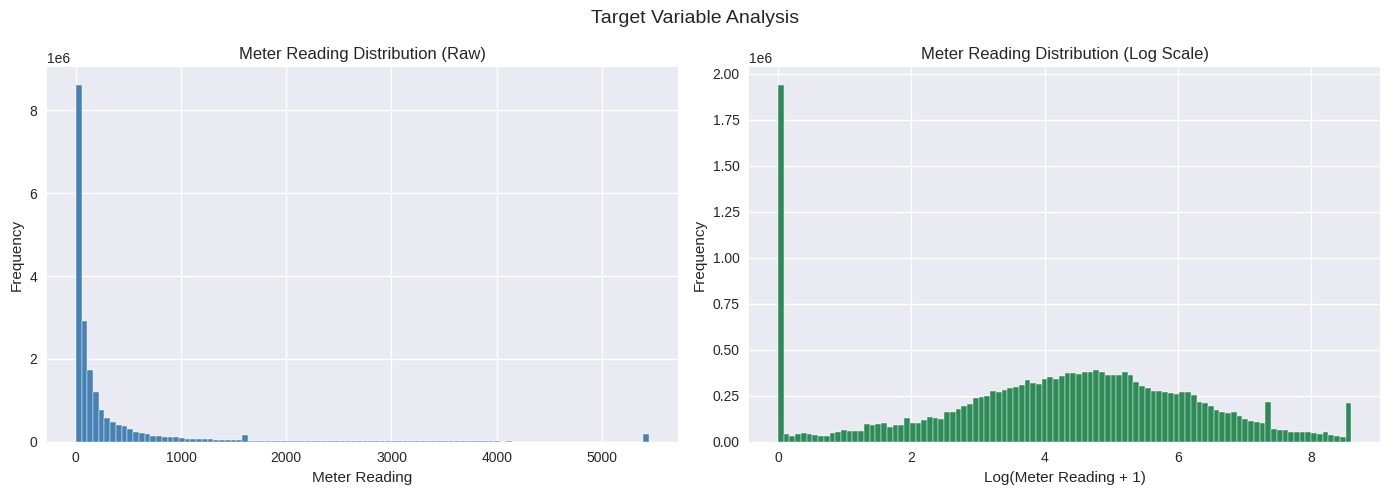


--- Readings per Meter Type ---
                  count   mean  median     max
meter_name                                    
Chilled Water   4182440 474.76  120.49 5449.22
Electricity    12060910 158.24   62.83 1629.61
Hot Water       1264037 264.60   39.62 3676.39
Steam           2708713 922.51  257.81 5449.22


In [17]:
print("=" * 50)
print("STEP 3 — TARGET VARIABLE ANALYSIS")
print("=" * 50)

print(f"\nTotal readings    : {len(df):,}")
print(f"Zero readings     : {(df['meter_reading'] == 0).sum():,} ({(df['meter_reading'] == 0).mean()*100:.1f}%)")
print(f"Negative readings : {(df['meter_reading'] < 0).sum():,}")
print(f"Mean reading      : {df['meter_reading'].mean():.2f}")
print(f"Median reading    : {df['meter_reading'].median():.2f}")
print(f"Max reading       : {df['meter_reading'].max():.2f}")

# Distribution plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['meter_reading'], bins=100,
             color='steelblue', edgecolor='white')
axes[0].set_title('Meter Reading Distribution (Raw)')
axes[0].set_xlabel('Meter Reading')
axes[0].set_ylabel('Frequency')

log_vals = np.log1p(df['meter_reading'])
axes[1].hist(log_vals, bins=100,
             color='seagreen', edgecolor='white')
axes[1].set_title('Meter Reading Distribution (Log Scale)')
axes[1].set_xlabel('Log(Meter Reading + 1)')
axes[1].set_ylabel('Frequency')

plt.suptitle('Target Variable Analysis', fontsize=14)
plt.tight_layout()
plt.show()

print("\n--- Readings per Meter Type ---")
print(df.groupby('meter_name')['meter_reading'].agg(
    ['count', 'mean', 'median', 'max']))

STEP 4 — TIME BASED ANALYSIS


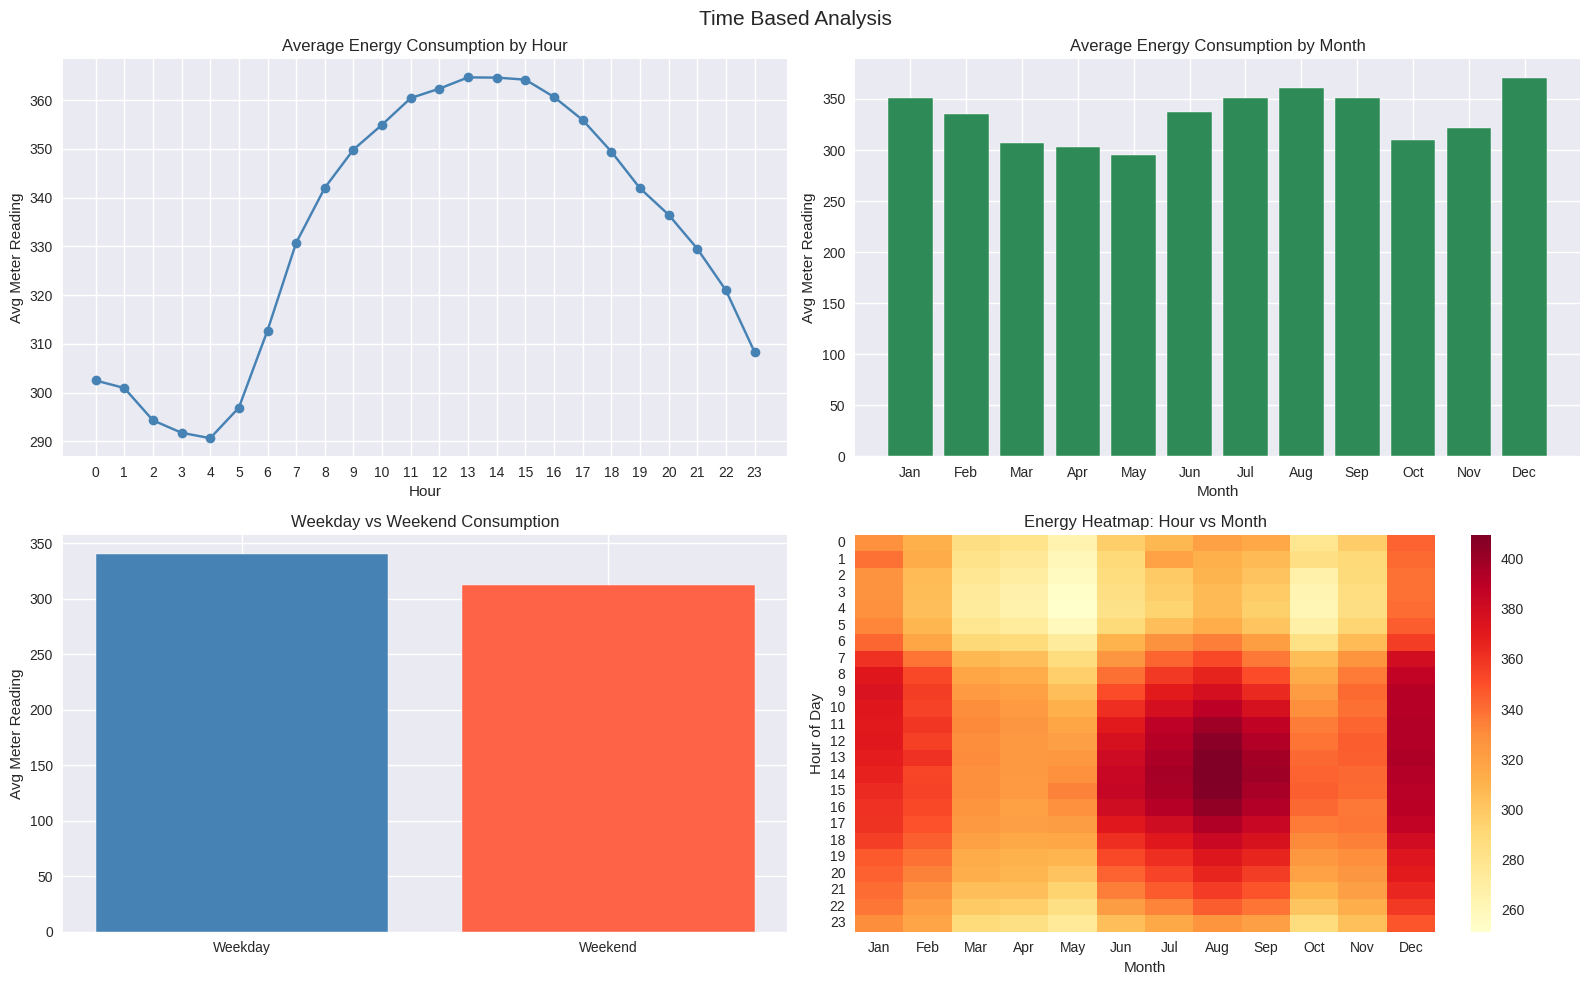

In [18]:
print("=" * 50)
print("STEP 4 — TIME BASED ANALYSIS")
print("=" * 50)

# Extract time features
df['hour']       = df['timestamp'].dt.hour
df['month']      = df['timestamp'].dt.month
df['weekday']    = df['timestamp'].dt.dayofweek
df['is_weekend'] = df['weekday'].isin([5, 6]).astype(int)

month_names = {1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr',
               5:'May', 6:'Jun', 7:'Jul', 8:'Aug',
               9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Energy by hour
hourly = df.groupby('hour')['meter_reading'].mean()
axes[0,0].plot(hourly.index, hourly.values,
               marker='o', color='steelblue')
axes[0,0].set_title('Average Energy Consumption by Hour')
axes[0,0].set_xlabel('Hour')
axes[0,0].set_ylabel('Avg Meter Reading')
axes[0,0].set_xticks(range(0, 24))

# Energy by month
monthly = df.groupby('month')['meter_reading'].mean()
axes[0,1].bar(monthly.index, monthly.values,
              color='seagreen', edgecolor='white')
axes[0,1].set_title('Average Energy Consumption by Month')
axes[0,1].set_xlabel('Month')
axes[0,1].set_ylabel('Avg Meter Reading')
axes[0,1].set_xticks(list(month_names.keys()))
axes[0,1].set_xticklabels(list(month_names.values()))

# Weekday vs Weekend
week_avg = df.groupby('is_weekend')['meter_reading'].mean()
axes[1,0].bar(['Weekday', 'Weekend'], week_avg.values,
              color=['steelblue', 'tomato'], edgecolor='white')
axes[1,0].set_title('Weekday vs Weekend Consumption')
axes[1,0].set_ylabel('Avg Meter Reading')

# Heatmap hour vs month
pivot = df.pivot_table(values='meter_reading',
                       index='hour',
                       columns='month',
                       aggfunc='mean')
sns.heatmap(pivot, ax=axes[1,1], cmap='YlOrRd',
            xticklabels=list(month_names.values()))
axes[1,1].set_title('Energy Heatmap: Hour vs Month')
axes[1,1].set_xlabel('Month')
axes[1,1].set_ylabel('Hour of Day')

plt.suptitle('Time Based Analysis', fontsize=15)
plt.tight_layout()
plt.show()

STEP 5 — BUILDING ANALYSIS


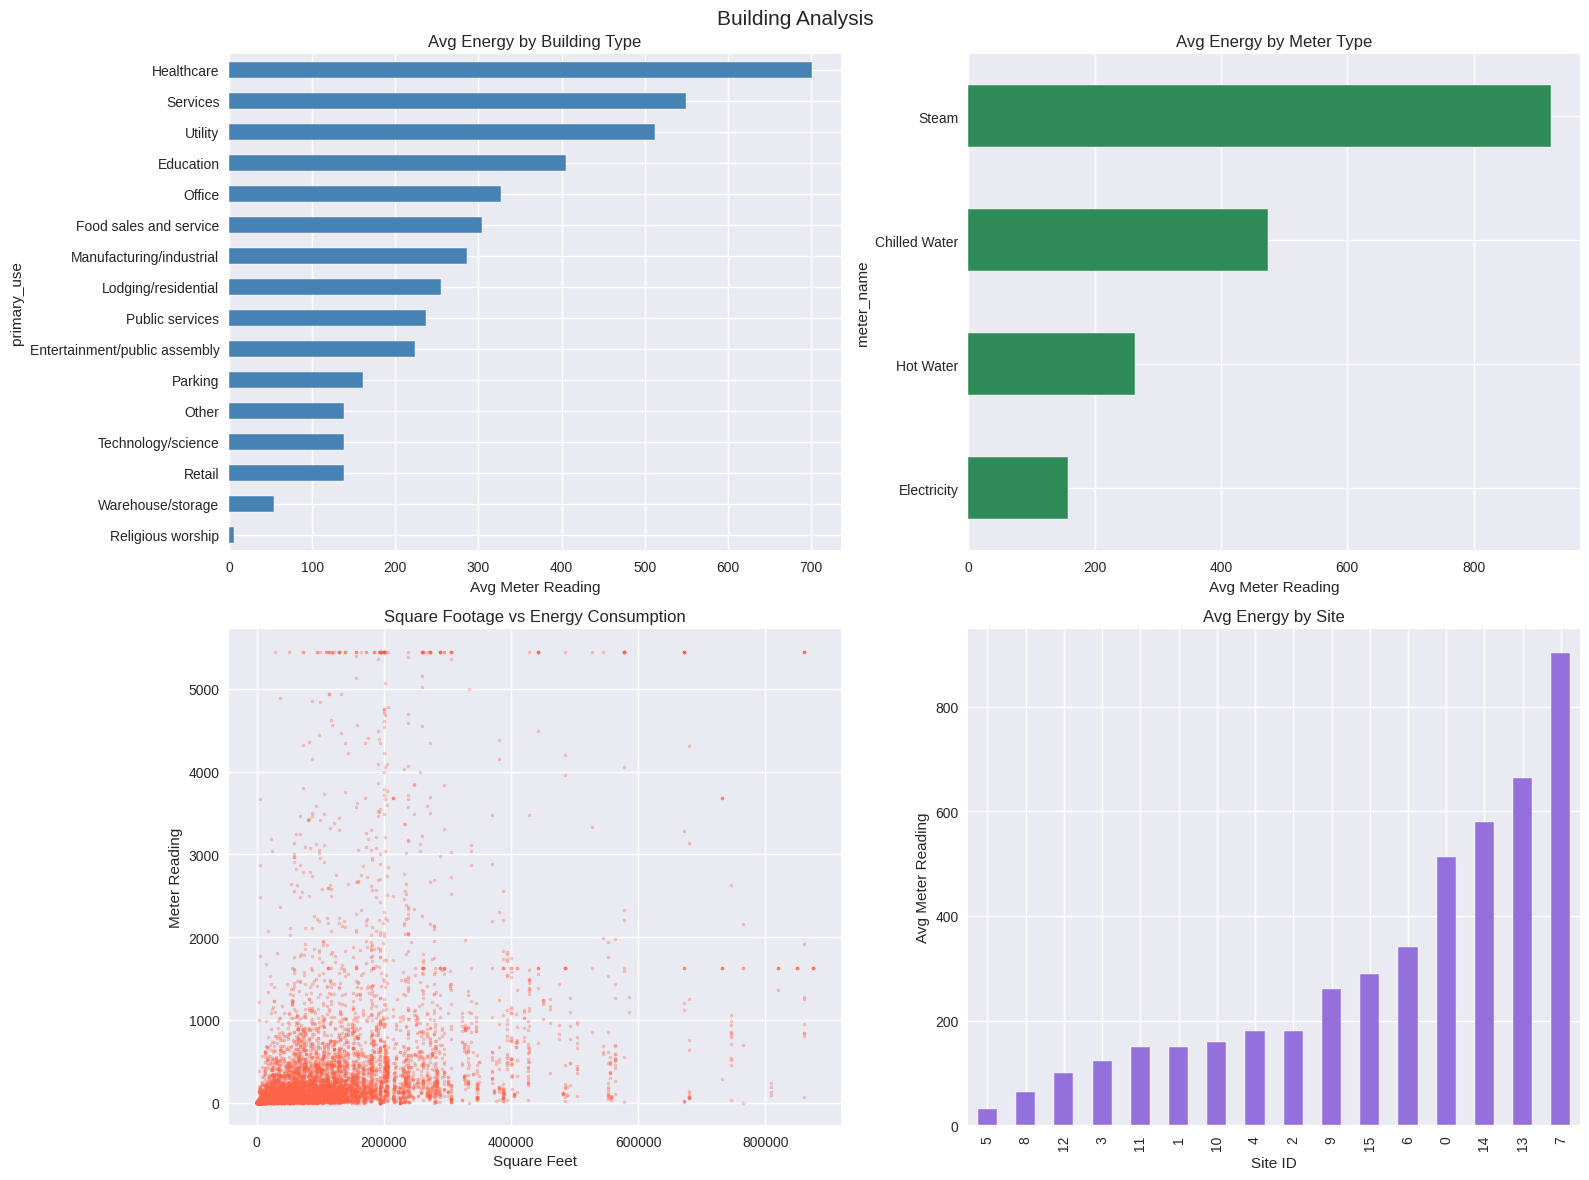

In [19]:
print("=" * 50)
print("STEP 5 — BUILDING ANALYSIS")
print("=" * 50)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Energy by building type
building_energy = df.groupby('primary_use')['meter_reading'] \
                    .mean().sort_values(ascending=True)
building_energy.plot(kind='barh', ax=axes[0,0],
                     color='steelblue', edgecolor='white')
axes[0,0].set_title('Avg Energy by Building Type')
axes[0,0].set_xlabel('Avg Meter Reading')

# Energy by meter type
meter_energy = df.groupby('meter_name')['meter_reading'] \
                 .mean().sort_values(ascending=True)
meter_energy.plot(kind='barh', ax=axes[0,1],
                  color='seagreen', edgecolor='white')
axes[0,1].set_title('Avg Energy by Meter Type')
axes[0,1].set_xlabel('Avg Meter Reading')

# Square footage vs energy
sample = df[df['meter_reading'] > 0].sample(10000, random_state=42)
axes[1,0].scatter(sample['square_feet'], sample['meter_reading'],
                  alpha=0.3, s=5, color='tomato')
axes[1,0].set_title('Square Footage vs Energy Consumption')
axes[1,0].set_xlabel('Square Feet')
axes[1,0].set_ylabel('Meter Reading')

# Energy by site
site_energy = df.groupby('site_id')['meter_reading'] \
                .mean().sort_values(ascending=True)
site_energy.plot(kind='bar', ax=axes[1,1],
                 color='mediumpurple', edgecolor='white')
axes[1,1].set_title('Avg Energy by Site')
axes[1,1].set_xlabel('Site ID')
axes[1,1].set_ylabel('Avg Meter Reading')

plt.suptitle('Building Analysis', fontsize=15)
plt.tight_layout()
plt.show()

STEP 5b — ENERGY TREND PER SITE OVER TIME


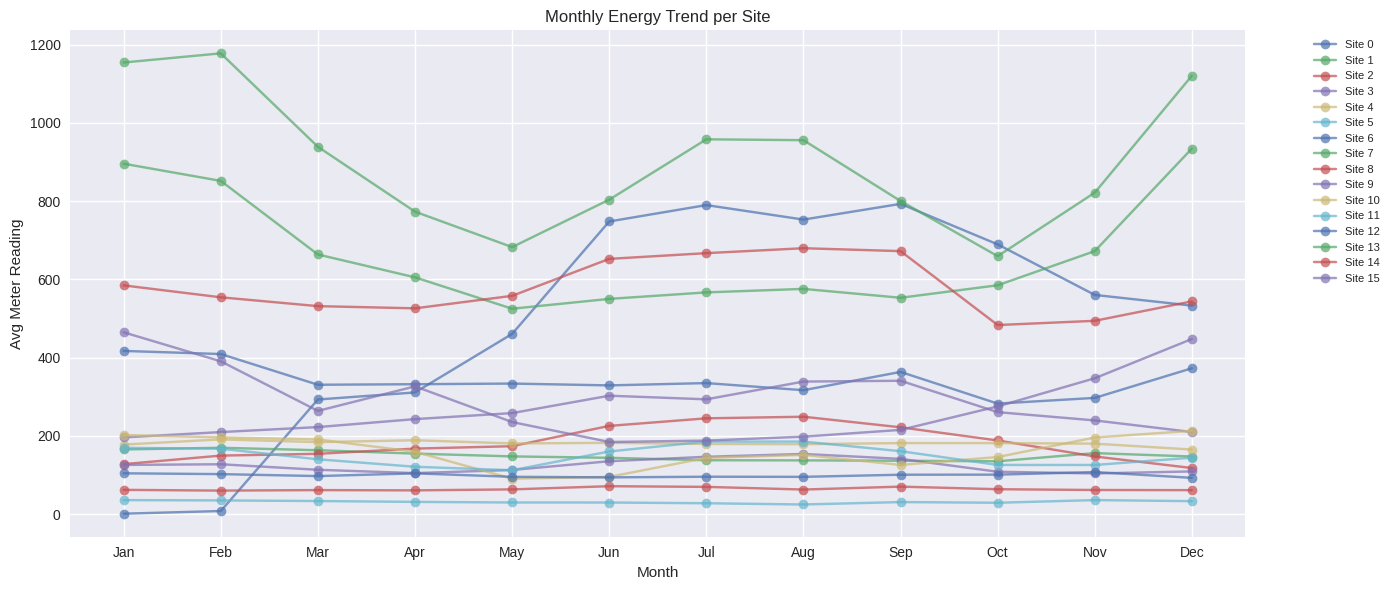

In [27]:
print("=" * 50)
print("STEP 5b — ENERGY TREND PER SITE OVER TIME")
print("=" * 50)

site_monthly = df.groupby(['site_id', 'month'])['meter_reading'].mean().reset_index()

plt.figure(figsize=(14, 6))
for site_id in df['site_id'].unique():
    site_data = site_monthly[site_monthly['site_id'] == site_id]
    plt.plot(site_data['month'], site_data['meter_reading'],
             marker='o', label=f'Site {site_id}', alpha=0.7)

plt.title('Monthly Energy Trend per Site')
plt.xlabel('Month')
plt.ylabel('Avg Meter Reading')
plt.xticks(list(range(1, 13)),
           ['Jan','Feb','Mar','Apr','May','Jun',
            'Jul','Aug','Sep','Oct','Nov','Dec'])
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

STEP 6 — WEATHER vs ENERGY RELATIONSHIP


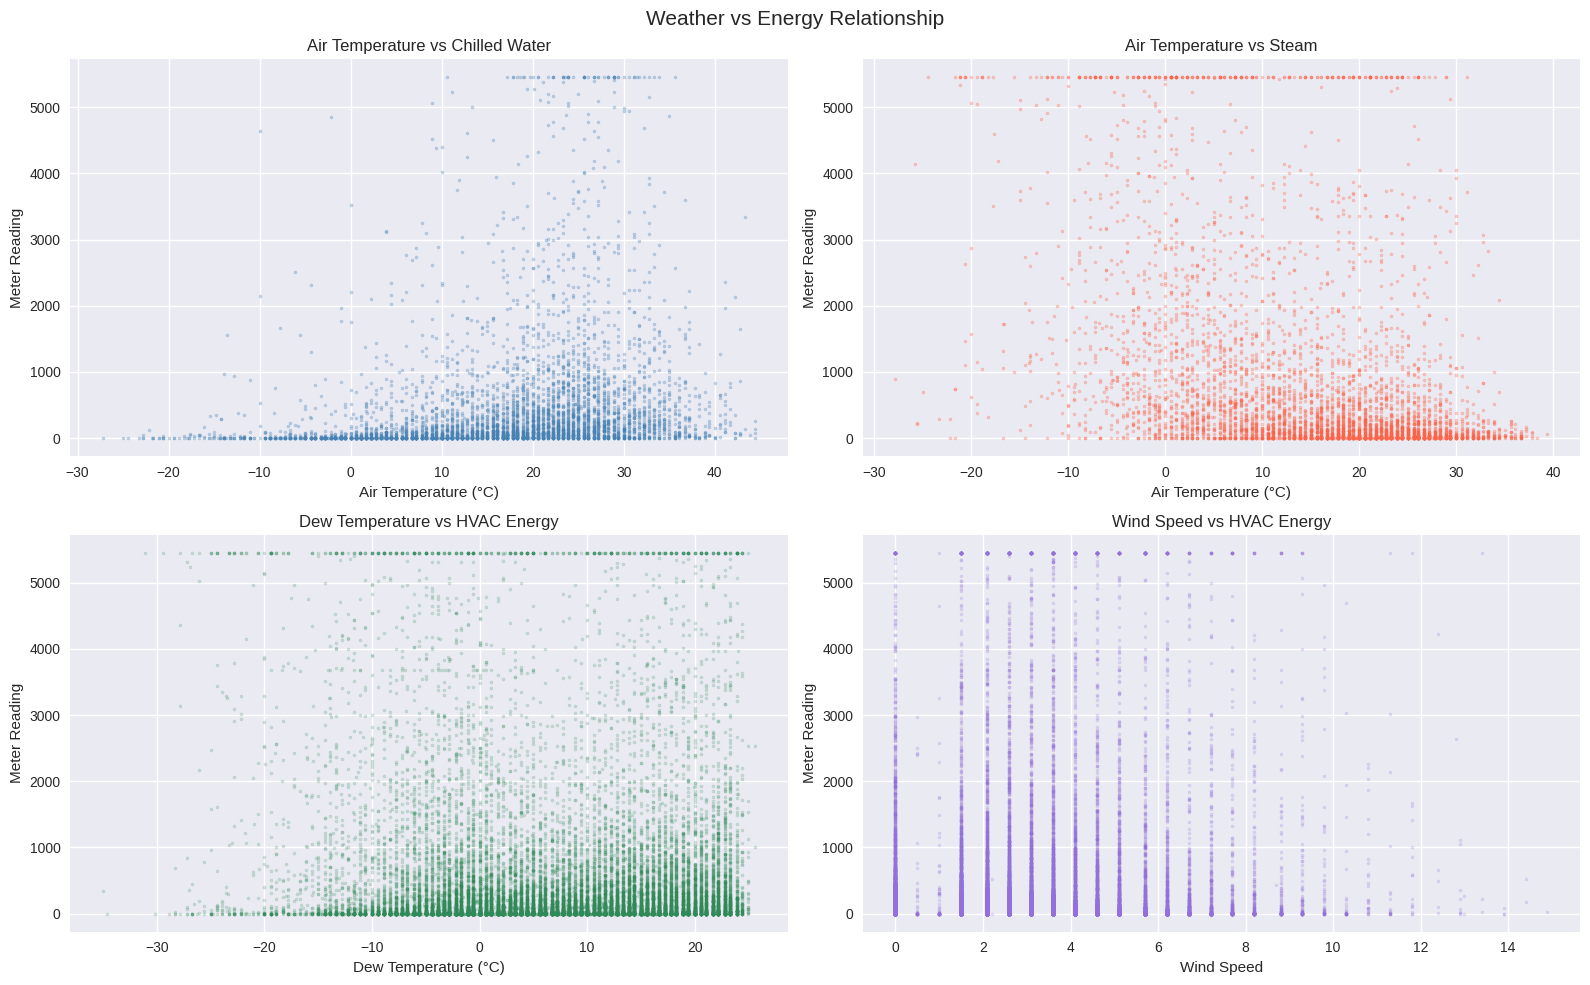

In [20]:
print("=" * 50)
print("STEP 6 — WEATHER vs ENERGY RELATIONSHIP")
print("=" * 50)

hvac_df = df[df['meter'].isin([1, 2, 3])].sample(20000, random_state=42)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Air temperature vs Chilled Water
cw = df[df['meter'] == 1].sample(5000, random_state=42)
axes[0,0].scatter(cw['air_temperature'], cw['meter_reading'],
                  alpha=0.3, s=5, color='steelblue')
axes[0,0].set_title('Air Temperature vs Chilled Water')
axes[0,0].set_xlabel('Air Temperature (°C)')
axes[0,0].set_ylabel('Meter Reading')

# Air temperature vs Steam
st = df[df['meter'] == 2].sample(5000, random_state=42)
axes[0,1].scatter(st['air_temperature'], st['meter_reading'],
                  alpha=0.3, s=5, color='tomato')
axes[0,1].set_title('Air Temperature vs Steam')
axes[0,1].set_xlabel('Air Temperature (°C)')
axes[0,1].set_ylabel('Meter Reading')

# Dew temperature vs energy
axes[1,0].scatter(hvac_df['dew_temperature'], hvac_df['meter_reading'],
                  alpha=0.2, s=5, color='seagreen')
axes[1,0].set_title('Dew Temperature vs HVAC Energy')
axes[1,0].set_xlabel('Dew Temperature (°C)')
axes[1,0].set_ylabel('Meter Reading')

# Wind speed vs energy
axes[1,1].scatter(hvac_df['wind_speed'], hvac_df['meter_reading'],
                  alpha=0.2, s=5, color='mediumpurple')
axes[1,1].set_title('Wind Speed vs HVAC Energy')
axes[1,1].set_xlabel('Wind Speed')
axes[1,1].set_ylabel('Meter Reading')

plt.suptitle('Weather vs Energy Relationship', fontsize=15)
plt.tight_layout()
plt.show()

STEP 7 — SKEWNESS & KURTOSIS ANALYSIS

--- Overall meter_reading ---
Skewness : 4.5270
Kurtosis : 23.3273

--- Per Meter Type (Raw) ---
        Meter  Skewness  Kurtosis    Skew Type
  Electricity      3.36     13.07 Right Skewed
Chilled Water      3.43     12.93 Right Skewed
        Steam      2.05      3.21 Right Skewed
    Hot Water      3.76     16.31 Right Skewed


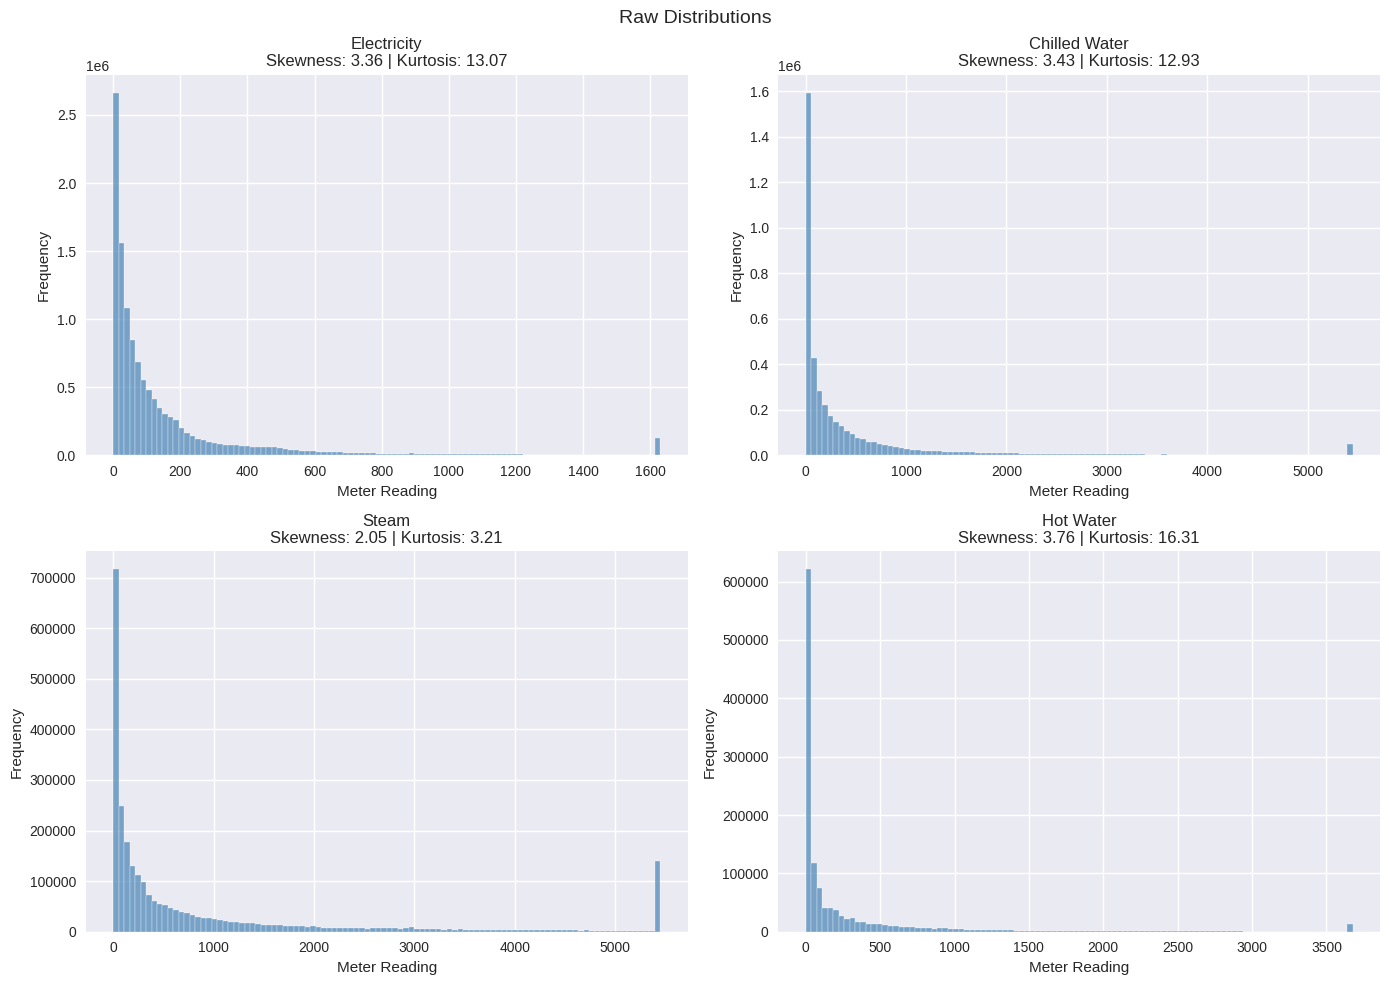


--- Per Meter Type (Log Transformed) ---


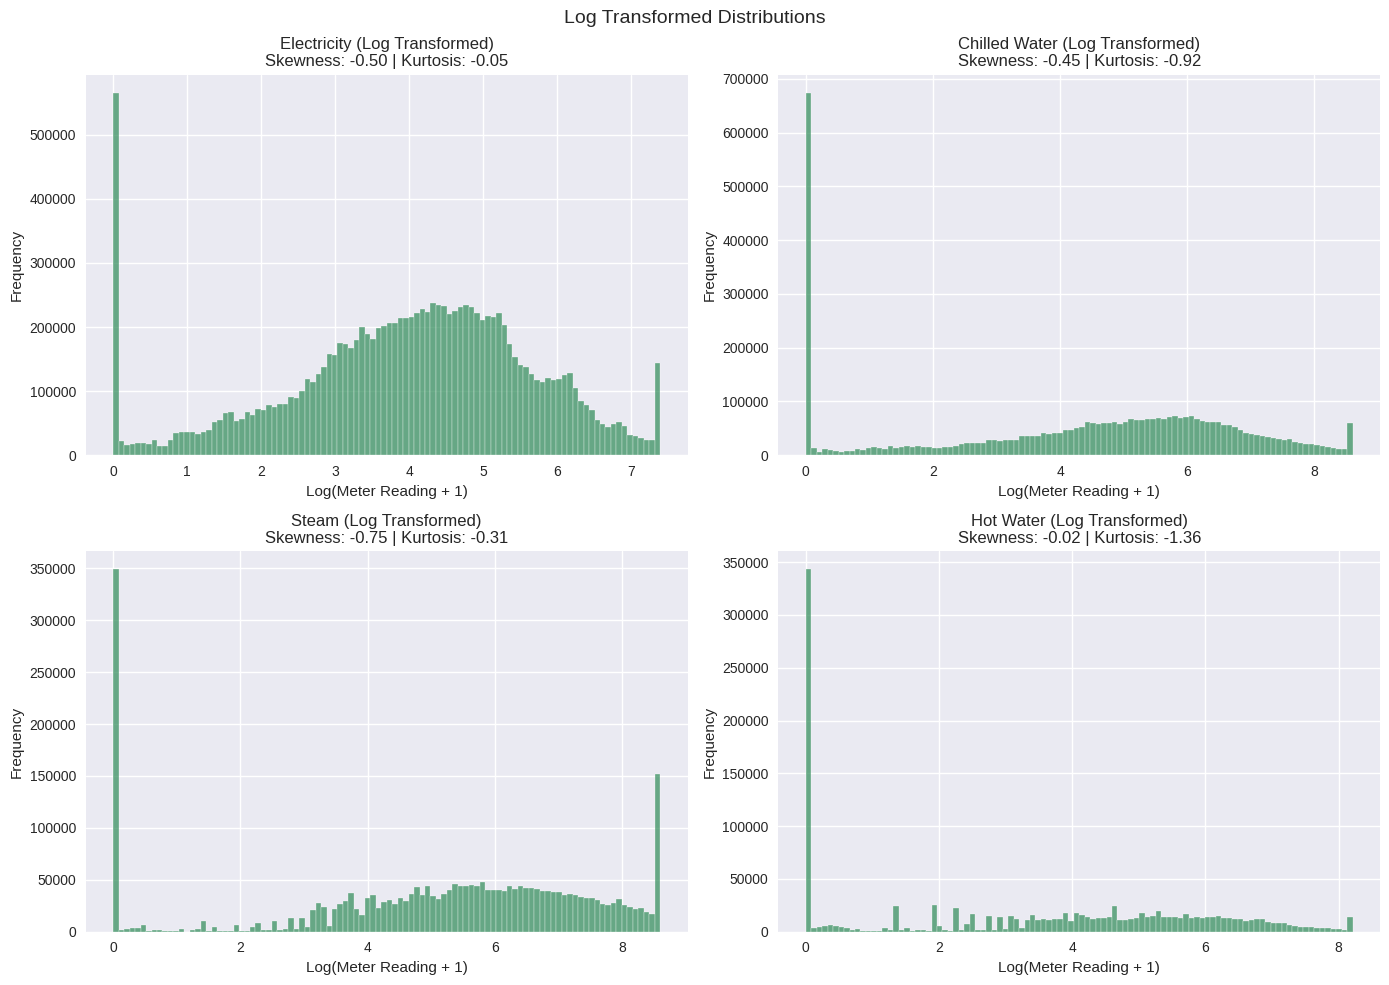

        Meter  Skewness  Kurtosis
  Electricity     -0.50     -0.05
Chilled Water     -0.45     -0.92
        Steam     -0.75     -0.31
    Hot Water     -0.02     -1.36


In [21]:
print("=" * 50)
print("STEP 7 — SKEWNESS & KURTOSIS ANALYSIS")
print("=" * 50)

print("\n--- Overall meter_reading ---")
print(f"Skewness : {df['meter_reading'].skew():.4f}")
print(f"Kurtosis : {df['meter_reading'].kurtosis():.4f}")

# Raw distributions
print("\n--- Per Meter Type (Raw) ---")
results = []
for meter_id, meter_name in meter_map.items():
    subset = df[df['meter'] == meter_id]['meter_reading']
    results.append({
        'Meter'     : meter_name,
        'Skewness'  : round(subset.skew(), 4),
        'Kurtosis'  : round(subset.kurtosis(), 4),
        'Skew Type' : 'Right Skewed' if subset.skew() > 1
                      else 'Mild Skew' if subset.skew() > 0.5
                      else 'Normal'
    })
print(pd.DataFrame(results).to_string(index=False))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for i, (meter_id, meter_name) in enumerate(meter_map.items()):
    ax = axes[i//2][i%2]
    subset = df[df['meter'] == meter_id]['meter_reading']
    ax.hist(subset, bins=100, color='steelblue',
            edgecolor='white', alpha=0.7)
    ax.set_title(f'{meter_name}\n'
                 f'Skewness: {subset.skew():.2f} | '
                 f'Kurtosis: {subset.kurtosis():.2f}')
    ax.set_xlabel('Meter Reading')
    ax.set_ylabel('Frequency')
plt.suptitle('Raw Distributions', fontsize=14)
plt.tight_layout()
plt.show()

# Log transformed distributions
print("\n--- Per Meter Type (Log Transformed) ---")
log_results = []
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for i, (meter_id, meter_name) in enumerate(meter_map.items()):
    ax = axes[i//2][i%2]
    subset = np.log1p(df[df['meter'] == meter_id]['meter_reading'])
    log_results.append({
        'Meter'    : meter_name,
        'Skewness' : round(subset.skew(), 4),
        'Kurtosis' : round(subset.kurtosis(), 4)
    })
    ax.hist(subset, bins=100, color='seagreen',
            edgecolor='white', alpha=0.7)
    ax.set_title(f'{meter_name} (Log Transformed)\n'
                 f'Skewness: {subset.skew():.2f} | '
                 f'Kurtosis: {subset.kurtosis():.2f}')
    ax.set_xlabel('Log(Meter Reading + 1)')
    ax.set_ylabel('Frequency')
plt.suptitle('Log Transformed Distributions', fontsize=14)
plt.tight_layout()
plt.show()

print(pd.DataFrame(log_results).to_string(index=False))

STEP 8 — CORRELATION ANALYSIS


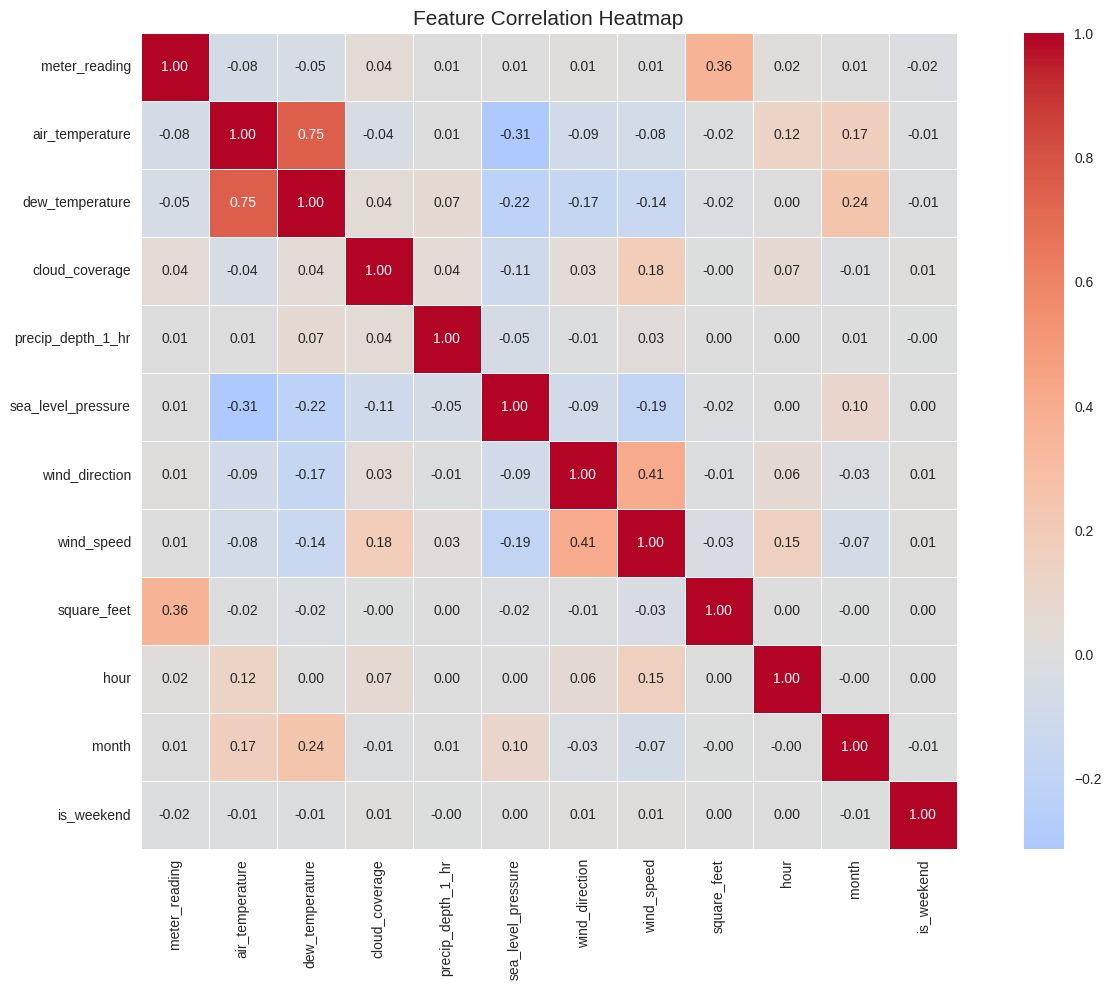


--- Top Correlations with meter_reading ---
square_feet           0.36
air_temperature      -0.08
dew_temperature      -0.05
cloud_coverage        0.04
hour                  0.02
is_weekend           -0.02
wind_direction        0.01
month                 0.01
wind_speed            0.01
sea_level_pressure    0.01
precip_depth_1_hr     0.01
Name: meter_reading, dtype: float64


In [22]:
print("=" * 50)
print("STEP 8 — CORRELATION ANALYSIS")
print("=" * 50)

num_cols = ['meter_reading', 'air_temperature', 'dew_temperature',
            'cloud_coverage', 'precip_depth_1_hr', 'sea_level_pressure',
            'wind_direction', 'wind_speed', 'square_feet',
            'hour', 'month', 'is_weekend']

corr_matrix = df[num_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=15)
plt.tight_layout()
plt.show()

print("\n--- Top Correlations with meter_reading ---")
corr_target = corr_matrix['meter_reading'] \
    .drop('meter_reading') \
    .sort_values(key=abs, ascending=False)
print(corr_target)

In [23]:
df['meter_reading_log'] = np.log1p(df['meter_reading'])

output_path = '/content/drive/MyDrive/hvac_project/eda_cleaned_data.parquet'
df.to_parquet(output_path, index=False)

print("✅ Final EDA data saved!")
print(f"   Shape   : {df.shape}")
print(f"   Columns : {df.columns.tolist()}")

✅ Final EDA data saved!
   Shape   : (20216100, 20)
   Columns : ['building_id', 'meter', 'timestamp', 'meter_reading', 'site_id', 'primary_use', 'square_feet', 'air_temperature', 'cloud_coverage', 'dew_temperature', 'precip_depth_1_hr', 'sea_level_pressure', 'wind_direction', 'wind_speed', 'meter_name', 'hour', 'month', 'weekday', 'is_weekend', 'meter_reading_log']
